In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# Cargamos el conjunto de datos
diabetes = load_diabetes()

# Creamos un DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

# Mostramos las primeras filas del DataFrame
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
sns.pairplot(df)

Output hidden; open in https://colab.research.google.com to view.

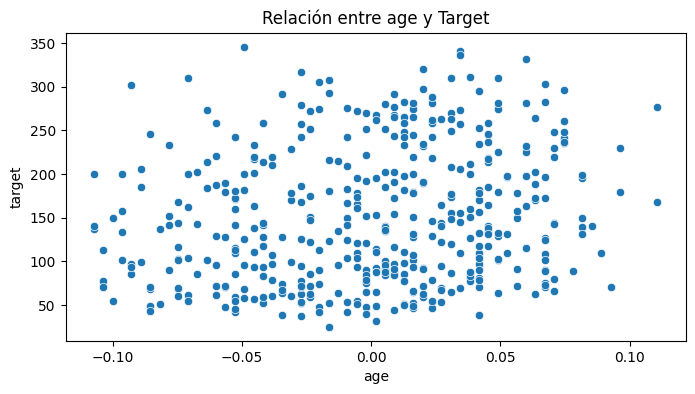

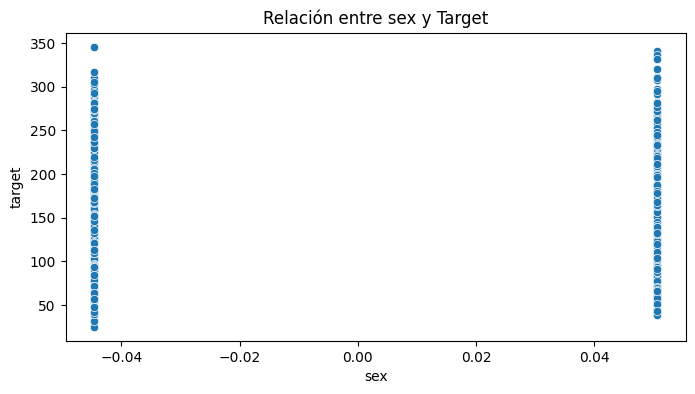

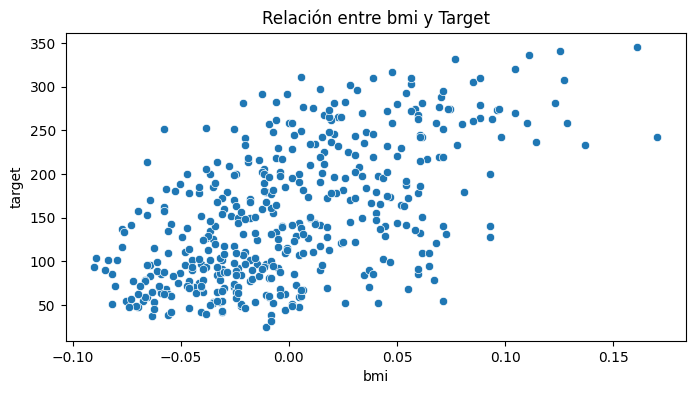

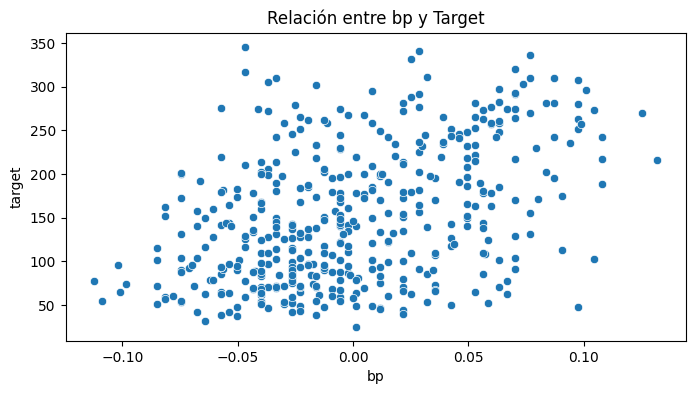

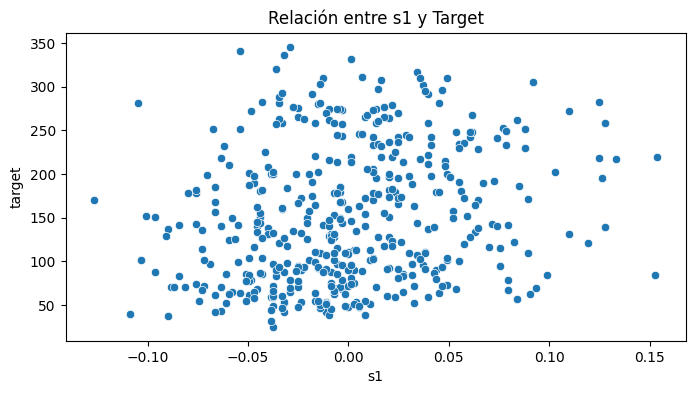

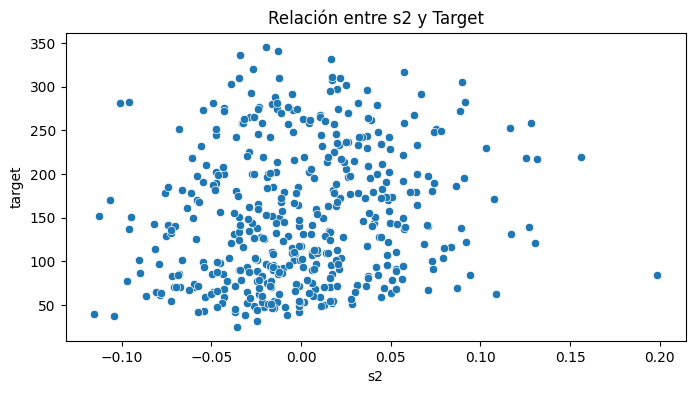

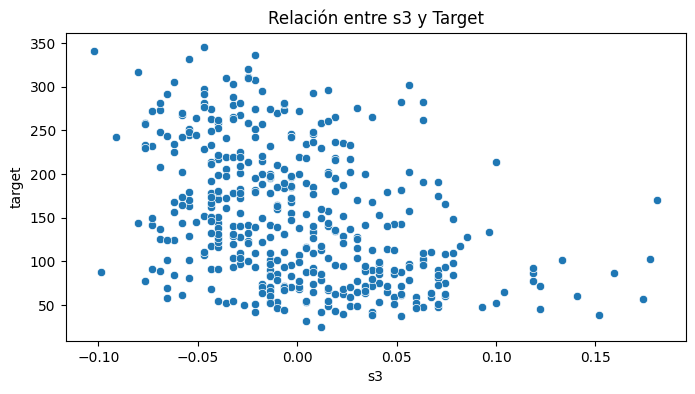

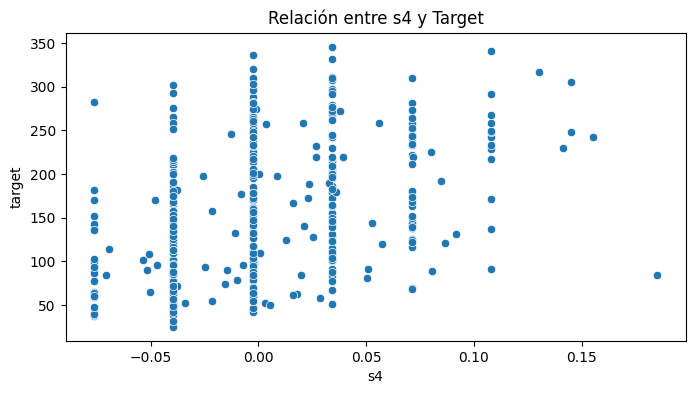

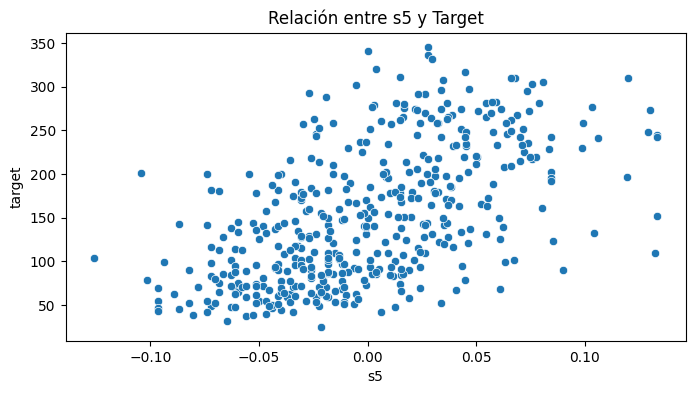

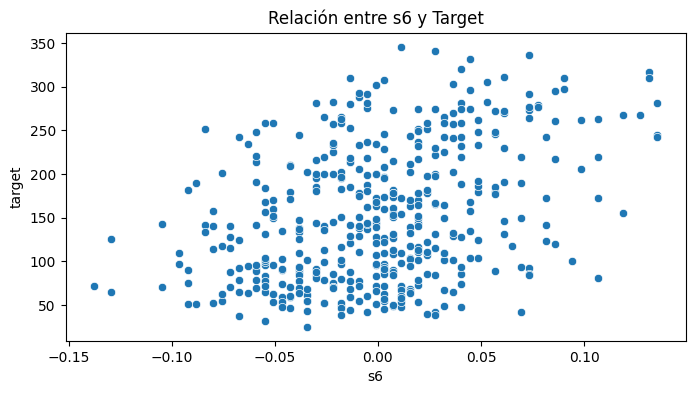

In [7]:
X = df.drop(columns='target')

# Visualizar la relación entre cada variable independiente y la variable dependiente
for i in X.columns:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(x=i, y='target', data=df)
    plt.title('Relación entre {} y Target'.format(i))
    plt.show()


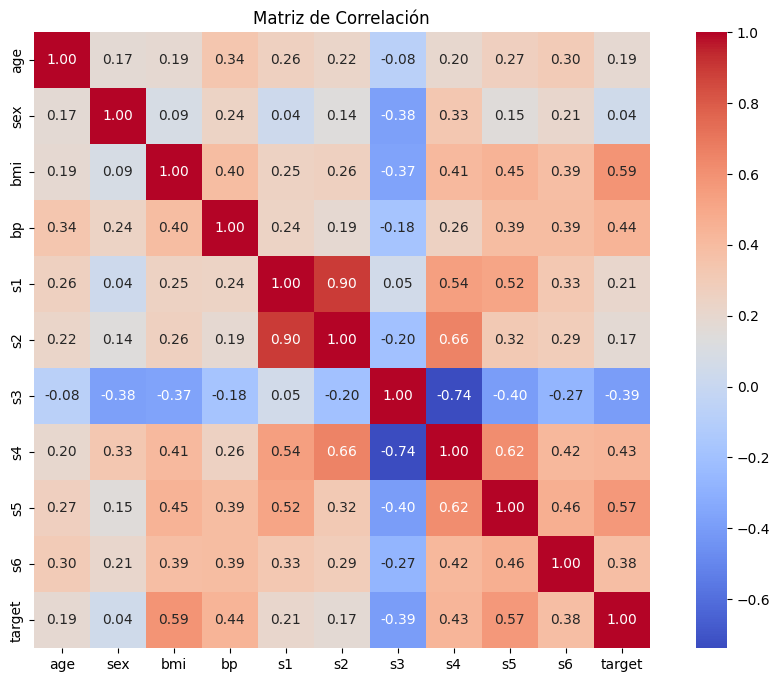

In [8]:
# Calcular la matriz de correlación
corr_matrix = df.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlación')
plt.show()


In [9]:
# Definimos las variables independientes (X) y la variable dependiente (y)
X = df.drop('target', axis=1)
y = df['target']

# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# Creamos una instancia del modelo de regresión lineal
modelo = LinearRegression()

# Entrenamos el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)


LinearRegression()

In [11]:
# Realizamos predicciones con el conjunto de prueba
y_pred = modelo.predict(X_test)

# Calculamos el error cuadrático medio
mse = mean_squared_error(y_test, y_pred)
print('Error Cuadrático Medio:', mse)


Error Cuadrático Medio: 2900.1936284934814


In [12]:
from sklearn.metrics import r2_score

# Calcular el coeficiente de determinación R^2
r2 = r2_score(y_test, y_pred)
print('Coeficiente de Determinación R^2:', r2)


Coeficiente de Determinación R^2: 0.4526027629719195


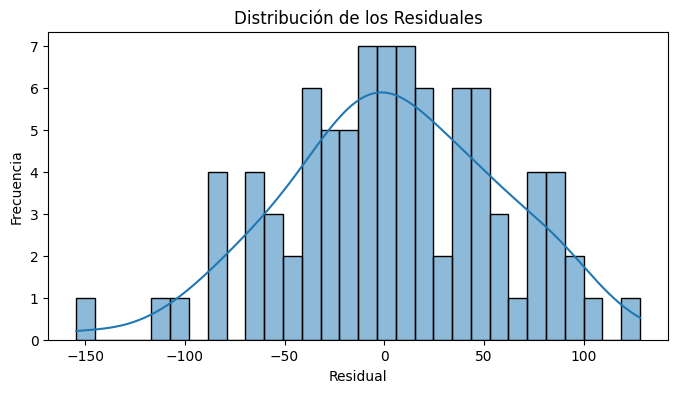

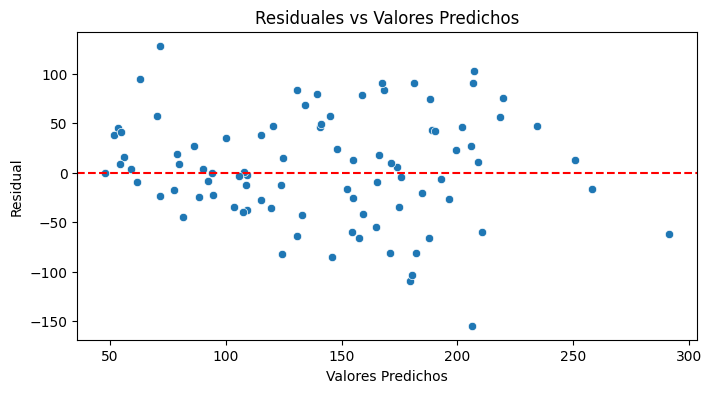

In [13]:
# Calcular los residuales
residuales = y_test - y_pred

# Visualizar la distribución de los residuales
plt.figure(figsize=(8, 4))
sns.histplot(residuales, kde=True, bins=30)
plt.title('Distribución de los Residuales')
plt.xlabel('Residual')
plt.ylabel('Frecuencia')
plt.show()

# Gráfico de dispersión para ver cómo se distribuyen los residuales con respecto a los valores predichos
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_pred, y=residuales)
plt.title('Residuales vs Valores Predichos')
plt.xlabel('Valores Predichos')
plt.ylabel('Residual')
plt.axhline(0, color='red', linestyle='--')
plt.show()


In [16]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Añadir una columna de unos a X_test para representar el intercepto
X_test_with_intercept = sm.add_constant(X_test)

# Realizar la prueba de Breusch-Pagan
bp_test_statistic, bp_p_value, _, _ = het_breuschpagan(residuales, X_test_with_intercept)
print('Prueba de Breusch-Pagan:')
print('Estadístico de prueba:', bp_test_statistic)
print('P-valor:', bp_p_value)

if bp_p_value < 0.05:
    print('Los residuos parecen no ser homocedásticos (se rechaza la hipótesis nula)')
else:
    print('Los residuos parecen ser homocedásticos (no se rechaza la hipótesis nula)')



Prueba de Breusch-Pagan:
Estadístico de prueba: 20.75149545828427
P-valor: 0.02289461762491943
Los residuos parecen no ser homocedásticos (se rechaza la hipótesis nula)


<Figure size 800x600 with 0 Axes>

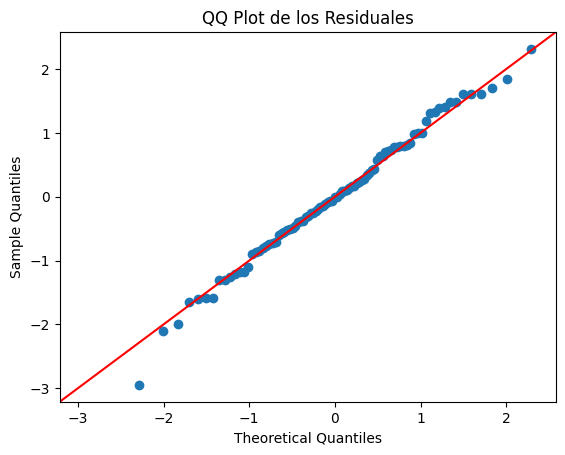

In [17]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generar el QQ-Plot
plt.figure(figsize=(8, 6))
sm.qqplot(residuales, fit=True, line='45')
plt.title('QQ Plot de los Residuales')
plt.show()


In [18]:
from scipy import stats

# Prueba de Shapiro-Wilk
shapiro_test_statistic, shapiro_p_value = stats.shapiro(residuales)
print('Prueba de Shapiro-Wilk:')
print('Estadístico de prueba:', shapiro_test_statistic)
print('P-valor:', shapiro_p_value)

# Prueba de Anderson-Darling
anderson_result = stats.anderson(residuales, dist='norm')
print('\nPrueba de Anderson-Darling:')
print('Estadístico de prueba:', anderson_result.statistic)
for i in range(len(anderson_result.critical_values)):
    sl, cv = anderson_result.significance_level[i], anderson_result.critical_values[i]
    if anderson_result.statistic < cv:
        print('%.3f: %.3f, Los datos parecen normales (a un nivel de significancia del %.1f%%)' % (sl, cv, sl))
    else:
        print('%.3f: %.3f, Los datos no parecen normales (a un nivel de significancia del %.1f%%)' % (sl, cv, sl))


Prueba de Shapiro-Wilk:
Estadístico de prueba: 0.9926697611808777
P-valor: 0.9066404700279236

Prueba de Anderson-Darling:
Estadístico de prueba: 0.1669945848853729
15.000: 0.553, Los datos parecen normales (a un nivel de significancia del 15.0%)
10.000: 0.630, Los datos parecen normales (a un nivel de significancia del 10.0%)
5.000: 0.755, Los datos parecen normales (a un nivel de significancia del 5.0%)
2.500: 0.881, Los datos parecen normales (a un nivel de significancia del 2.5%)
1.000: 1.048, Los datos parecen normales (a un nivel de significancia del 1.0%)


<ipython-input-22-6550fb4221a7>:22: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(leverage, use_line_collection=True)


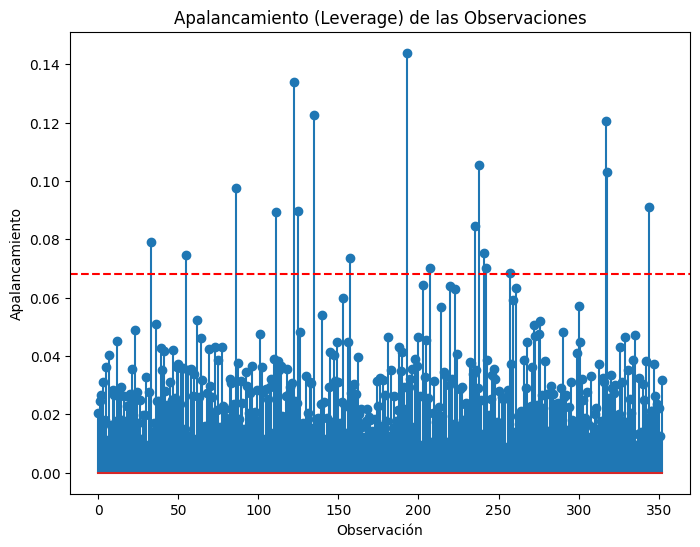

In [22]:
import numpy as np
import pandas as pd

# Asegurándonos de que X_train es un array de numpy
X_train_np = X_train.to_numpy() if isinstance(X_train, pd.DataFrame) else np.asarray(X_train)

# Añadiendo la constante
X_train_with_intercept = sm.add_constant(X_train_np)

# Calculando la matriz de proyección H
H = X_train_with_intercept @ np.linalg.inv(X_train_with_intercept.T @ X_train_with_intercept) @ X_train_with_intercept.T

# Calculando el apalancamiento
leverage = np.diag(H)

# Calculando el umbral de apalancamiento excesivo (2*(k+1)/n)
n, k = X_train_with_intercept.shape
leverage_threshold = 2 * (k + 1) / n

# Visualizando el apalancamiento
plt.figure(figsize=(8,6))
plt.stem(leverage, use_line_collection=True)
plt.axhline(y=leverage_threshold, color='r', linestyle='--')
plt.title('Apalancamiento (Leverage) de las Observaciones')
plt.xlabel('Observación')
plt.ylabel('Apalancamiento')
plt.show()

Puntos influyentes basados en la Distancia de Cook:
[  0   2   6  15  17  18  19  20  22  24  26  28  29  30  32  33  34  36
  39  40  41  47  48  52  53  55  56  60  63  64  66  67  69  70  71  74
  75  76  78  81  82  83  84  86  89  90  91  92  93  94  98 100 102 103
 104 106 107 108 111 112 113 114 116 117 119 120 121 122 123 125 126 127
 128 131 132 136 138 139 140 144 145 146 147 148 149 152 158 159 160 161
 162 169 173 174 175 176 177 178 180 181 182 183 187 189 193 197 198 200
 201 202 206 209 210 211 213 214 219 220 221 223 227 228 233 234 235 237
 239 241 245 246 250 252 253 255 256 260 261 262 263 265 266 268 269 270
 277 278 280 281 282 284 285 287 289 292 293 296 299 300 301 303 304 305
 306 307 309 310 311 316 317 318 320 321 322 323 324 326 327 328 331 332
 334 335 337 338 341 342 345 347 348 351 352]


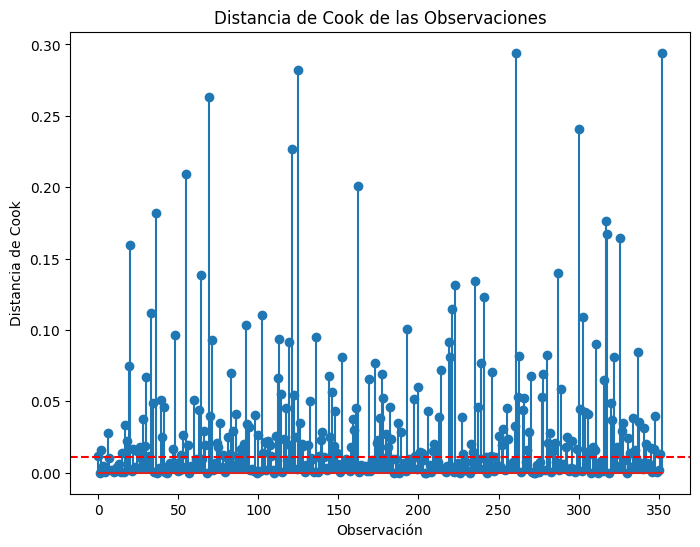

In [23]:
# Calcular residuales
residuales_train = y_train - modelo.predict(X_train)

# Calcular la varianza de los residuales
s2 = np.mean(residuales_train**2)

# Calcular la distancia de Cook
distancia_cook = (residuales_train**2 / s2) * (leverage / (1 - leverage))

# Identificar puntos influyentes (umbral común: 4/n)
umbral = 4 / len(X_train)
puntos_influyentes = np.where(distancia_cook > umbral)[0]

# Mostrar resultados
print("Puntos influyentes basados en la Distancia de Cook:")
print(puntos_influyentes)

# Visualizar la Distancia de Cook
plt.figure(figsize=(8,6))
plt.stem(distancia_cook)
plt.axhline(y=umbral, color='r', linestyle='--')
plt.title('Distancia de Cook de las Observaciones')
plt.xlabel('Observación')
plt.ylabel('Distancia de Cook')
plt.show()


Banda de Confianza para las Predicciones en el Conjunto de Test

La banda de confianza para las predicciones se puede calcular utilizando la fórmula de los intervalos de predicción. Para una regresión lineal, el intervalo de predicción para una nueva observación \(x_0\) se puede calcular como:

$$ \hat{y}_0 \pm t_{\alpha/2, n-p} \cdot \sqrt{MSE \cdot \left(1 + x_0^T(X^TX)^{-1}x_0\right)} $$


Donde:
- $ \hat{y}_0 $ es la predicción para \(x_0\),
- $ t_{\alpha/2, n-p} $ es el valor crítico de la distribución t para un nivel de confianza del $(1 - \alpha)$ y \( n-p \) grados de libertad,
- $ n $ es el número de observaciones,
- $ p $ es el número de parámetros,
- $ MSE $ es el Error Cuadrático Medio de los residuos.

A continuación se muestra cómo calcular e ilustrar la banda de confianza para las predicciones:

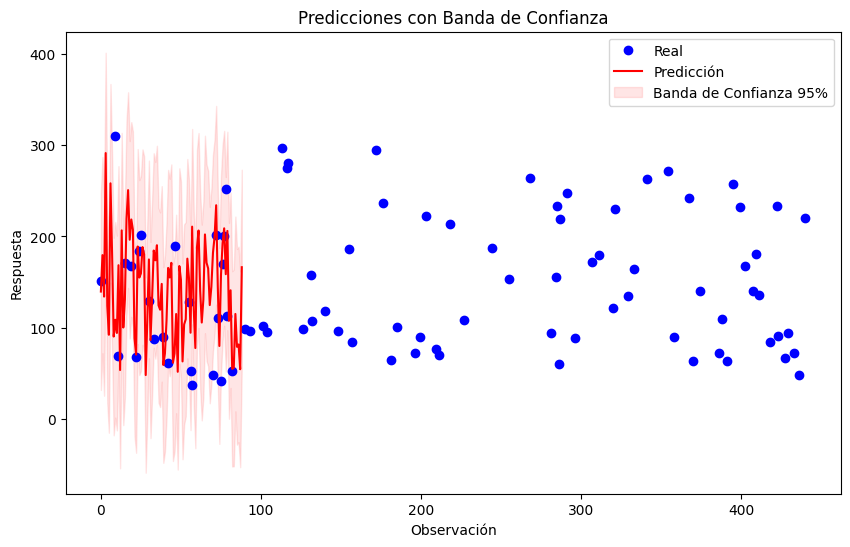

In [24]:
from scipy.stats import t

# Nivel de confianza
alpha = 0.05

# Número de parámetros (incluyendo el intercepto)
p = X_train_with_intercept.shape[1]

# Número de observaciones
n = len(X_train)

# Grados de libertad
df = n - p


# Valor crítico de t
t_value = t.ppf(1 - alpha/2, df)

# Error Estándar de la Predicción
X_test_with_intercept = np.hstack([np.ones((X_test.shape[0], 1)), X_test])
se_pred = np.sqrt(mse * (1 + np.sum(X_test_with_intercept @ np.linalg.inv(X_train_with_intercept.T @ X_train_with_intercept) * X_test_with_intercept, axis=1)))

# Intervalo de Predicción
ci_lower = y_pred - t_value * se_pred
ci_upper = y_pred + t_value * se_pred

# Visualizar
plt.figure(figsize=(10, 6))
plt.plot(y_test, 'bo', label='Real')
plt.plot(y_pred, 'r-', label='Predicción')
plt.fill_between(range(len(y_test)), ci_lower, ci_upper, color='r', alpha=0.1, label='Banda de Confianza 95%')
plt.legend()
plt.title('Predicciones con Banda de Confianza')
plt.xlabel('Observación')
plt.ylabel('Respuesta')
plt.show()


In [ ]:
# Imprimimos los coeficientes del modelo
print('Coeficientes:', modelo.coef_)
print('Intercepto:', modelo.intercept_)


Coeficientes: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
Intercepto: 151.34560453985995


### Intervalo de Confianza para los Coeficientes

Para calcular el intervalo de confianza de los coeficientes en un modelo de regresión lineal, puedes usar la fórmula:

$$ \hat{\beta}_j \pm t_{\alpha/2, n-p} \cdot \text{SE}(\hat{\beta}_j) $$

Donde:
- $ \hat{\beta}_j $ es el estimador del $ j $-ésimo coeficiente,
- $ t_{\alpha/2, n-p} $ es el valor crítico de la distribución t para un nivel de confianza del $ (1 - \alpha) $ y $ n-p $ grados de libertad,
- $ n $ es el número de observaciones,
- $ p $ es el número de parámetros,
- $ \text{SE}(\hat{\beta}_j) $ es el error estándar del $ j $-ésimo coeficiente, que se puede estimar como:

$$ \text{SE}(\hat{\beta}_j) = \sqrt{ \text{MSE} \cdot \left( (X^TX)^{-1} \right)_{jj} } $$

Donde $ \text{MSE} $ es el error cuadrático medio de los residuales.

A continuación, se muestra cómo implementarlo:

In [25]:

from scipy.stats import t
import numpy as np

# Nivel de confianza
alpha = 0.05

# Número de observaciones y parámetros
n, p = X_train_with_intercept.shape

# Grados de libertad
df = n - p

# Valor crítico de t
t_value = t.ppf(1 - alpha/2, df)

# Calcular el Error Cuadrático Medio de los residuales
mse = np.mean(residuales**2)

# Calcular la matriz de varianzas y covarianzas de los coeficientes
cov_matrix = mse * np.linalg.inv(X_train_with_intercept.T @ X_train_with_intercept)

# Calcular el error estándar de los coeficientes
se = np.sqrt(np.diag(cov_matrix))

# Añadir el intercepto a beta
beta = np.insert(modelo.coef_, 0, modelo.intercept_)

# Calcular el intervalo de confianza
ci_lower = beta - t_value * se
ci_upper = beta + t_value * se

# Obtener los nombres de las variables
variable_names = ['Intercepto'] + list(X_train.columns)

# Crear un DataFrame para almacenar los resultados
results_df = pd.DataFrame({
    'Coeficiente': variable_names,
    'Valor': beta,
    'Error Estándar': se,
    'IC 95% Inferior': ci_lower,
    'IC 95% Superior': ci_upper
})

print(results_df)


   Coeficiente       Valor  Error Estándar  IC 95% Inferior  IC 95% Superior
0   Intercepto  151.345605        2.871979       145.696638       156.994571
1          age   37.904021       68.345100       -96.525640       172.333683
2          sex -241.964362       67.864044      -375.447823      -108.480902
3          bmi  542.428759       76.164022       392.619866       692.237651
4           bp  347.703844       70.622540       208.794630       486.613058
5           s1 -931.488846      446.496191     -1809.713209       -53.264483
6           s2  518.062277      360.367121      -190.752695      1226.877249
7           s3  163.419983      230.616392      -290.185082       617.025048
8           s4  275.317902      183.491983       -85.597002       636.232805
9           s5  736.198859      190.457159       361.583978      1110.813740
10          s6   48.670657       72.679813       -94.285057       191.626372


In [ ]:
import pandas as pd

# Crear un DataFrame para almacenar los resultados
results_df = pd.DataFrame({
    'Coeficiente': ['Intercepto'] + [f'X{i}' for i in range(1, p)],
    'Valor': [modelo.intercept_] + list(modelo.coef_),
    'Error Estándar': [se[0]] + list(se[1:]),
})

# Calcular los límites del intervalo de confianza
results_df['IC 95% Inferior'] = results_df['Valor'] - t_value * results_df['Error Estándar']
results_df['IC 95% Superior'] = results_df['Valor'] + t_value * results_df['Error Estándar']

print(results_df)
